## 1️. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

## 2️. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv(
    '/content/combine.csv',
    engine='python',
    on_bad_lines='skip'
)

#  Reduce dataset size for faster training
df = df.sample(n=200000, random_state=42)

# Inspect data
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1400724 to 1443261
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             200000 non-null  object 
 1    Flow Duration                200000 non-null  float64
 2    Total Fwd Packets            200000 non-null  float64
 3    Total Backward Packets       200000 non-null  float64
 4   Total Length of Fwd Packets   200000 non-null  float64
 5    Total Length of Bwd Packets  200000 non-null  float64
 6    Fwd Packet Length Max        200000 non-null  float64
 7    Fwd Packet Length Min        200000 non-null  float64
 8    Fwd Packet Length Mean       200000 non-null  float64
 9    Fwd Packet Length Std        200000 non-null  float64
 10  Bwd Packet Length Max         200000 non-null  float64
 11   Bwd Packet Length Min        200000 non-null  float64
 12   Bwd Packet Length Mean       200000 non-n

In [3]:
# Reduce dataset size for faster training
df = df.sample(n=200000, random_state=42)

# Convert Destination Port to numeric
df[' Destination Port'] = pd.to_numeric(df[' Destination Port'], errors='coerce')

# Convert ALL columns to numeric where possible
df = df.apply(pd.to_numeric, errors='ignore')

# Remove infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Check dataset shape
df.shape

/tmp/ipykernel_1619/3643106084.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


(199785, 79)

In [4]:
# Feature / Target split
X = df.drop(' Label', axis=1)
y = df[' Label']

# Keep only numeric columns (important for ANN/CNN)
X = X.select_dtypes(include=['int64','float64'])

# Replace infinities
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
X.fillna(0, inplace=True)

# Encode target labels to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to float32 (important for deep learning)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (159828, 78)
Test shape: (39957, 78)


## MACHINE LEARNING MODELS

## Model 1 — Logistic Regression

Logistic Regression Accuracy: 0.9728958630527818

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     30175
           1       0.00      0.00      0.00        46
           2       0.99      0.99      0.99      2313
           3       0.99      0.89      0.94       176
           4       0.94      1.00      0.97      4227
           5       0.83      0.84      0.83        99
           6       0.87      0.56      0.68       105
           8       0.82      1.00      0.90      2816

    accuracy                           0.97     39957
   macro avg       0.80      0.78      0.79     39957
weighted avg       0.97      0.97      0.97     39957



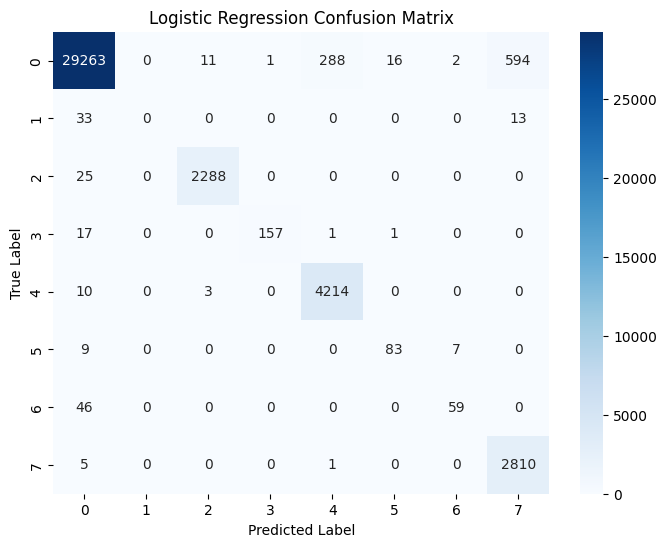

In [5]:
## Model 1 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create model
lr = LogisticRegression(max_iter=1000, n_jobs=-1)

# Train model
lr.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

# Evaluation metrics (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_test, pred_lr, zero_division=0))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Model 2 — Decision Tree

Decision Tree Accuracy: 0.9978476862627325

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30175
           1       0.79      0.74      0.76        46
           2       1.00      1.00      1.00      2313
           3       0.98      0.97      0.98       176
           4       1.00      1.00      1.00      4227
           5       0.92      0.96      0.94        99
           6       0.99      0.95      0.97       105
           8       0.99      1.00      1.00      2816

    accuracy                           1.00     39957
   macro avg       0.96      0.95      0.96     39957
weighted avg       1.00      1.00      1.00     39957



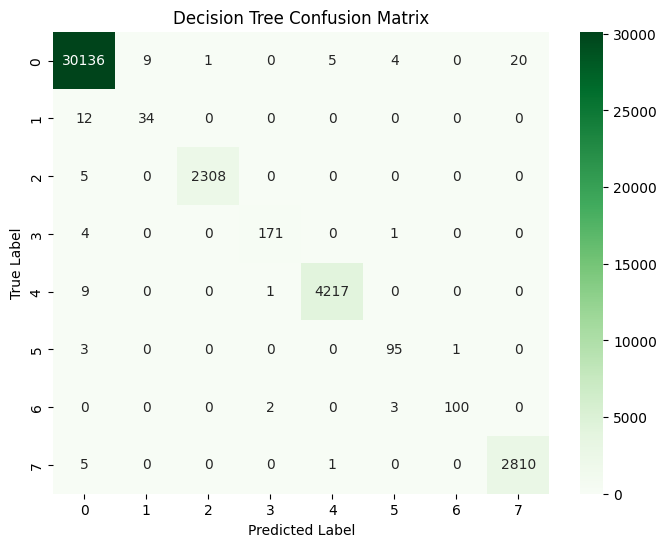

In [6]:
## Model 2 — Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create model
dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

# Train model
dt.fit(X_train, y_train)

# Predictions
pred_dt = dt.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, pred_dt)
print("Decision Tree Accuracy:", acc_dt)

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, pred_dt, zero_division=0))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Model 3 — Random Forest

Random Forest Accuracy: 0.9979728207823411

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30175
           1       0.92      0.48      0.63        46
           2       1.00      1.00      1.00      2313
           3       1.00      0.98      0.99       176
           4       1.00      1.00      1.00      4227
           5       0.99      0.98      0.98        99
           6       1.00      1.00      1.00       105
           8       0.99      1.00      0.99      2816

    accuracy                           1.00     39957
   macro avg       0.99      0.93      0.95     39957
weighted avg       1.00      1.00      1.00     39957



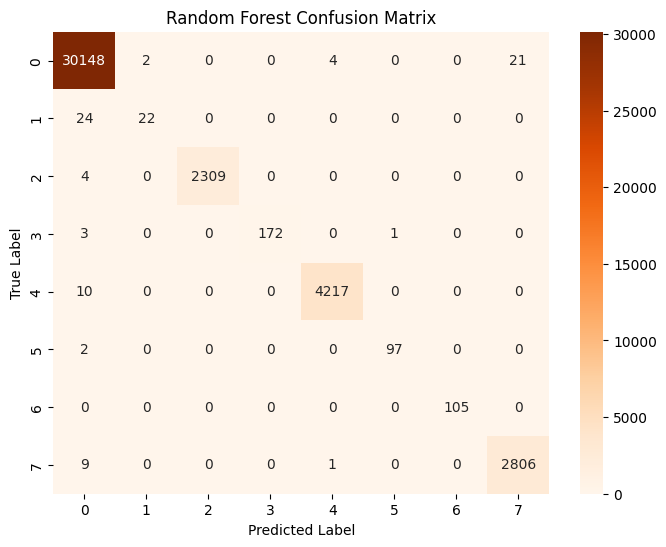

In [7]:
## Model 3 — Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

# Predictions
pred_rf = rf.predict(X_test)

# Accuracy
acc_rf = accuracy_score(y_test, pred_rf)
print("Random Forest Accuracy:", acc_rf)

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, pred_rf, zero_division=0))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Model 4 — KNN

KNN Accuracy: 0.9927922516705459

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     30175
           1       0.86      0.41      0.56        46
           2       1.00      0.99      1.00      2313
           3       0.94      0.97      0.96       176
           4       0.99      1.00      0.99      4227
           5       0.96      0.98      0.97        99
           6       0.99      0.96      0.98       105
           8       0.96      0.98      0.97      2816

    accuracy                           0.99     39957
   macro avg       0.96      0.91      0.93     39957
weighted avg       0.99      0.99      0.99     39957



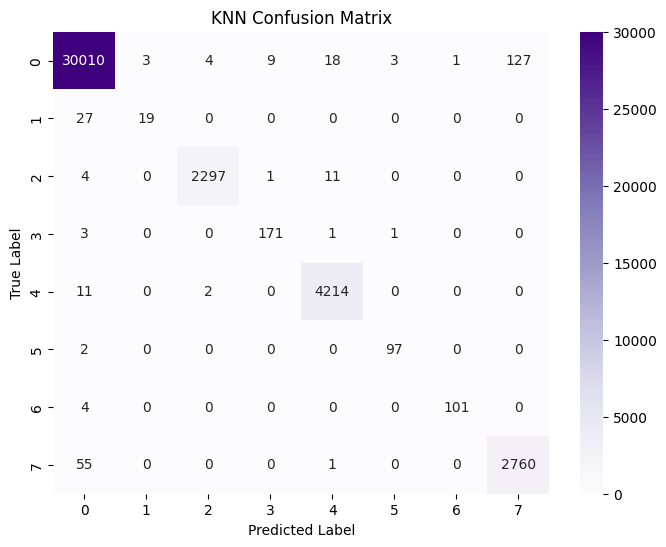

In [8]:
## Model 4 — KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create model
knn = KNeighborsClassifier(
    n_neighbors=7,
    algorithm='ball_tree',
    n_jobs=-1
)

# Train model
knn.fit(X_train, y_train)

# Predictions
pred_knn = knn.predict(X_test)

# Accuracy
acc_knn = accuracy_score(y_test, pred_knn)
print("KNN Accuracy:", acc_knn)

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, pred_knn, zero_division=0))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples')

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Model 5 — Artificial Neural Network (ANN)

In [10]:
## Model 5 — Artificial Neural Network (ANN)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

# Create ANN model
ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

# Compile model
ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_ann = ann.fit(
    X_train,
    y_train,
    epochs=5,          # reduced for faster training
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Evaluate model
ann_loss, ann_acc = ann.evaluate(X_test, y_test)

print("ANN Accuracy:", ann_acc)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9220 - loss: 0.2695 - val_accuracy: 0.9620 - val_loss: 0.1005
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9679 - loss: 0.0786 - val_accuracy: 0.9708 - val_loss: 0.0723
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0602 - val_accuracy: 0.9759 - val_loss: 0.0560
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9814 - loss: 0.0487 - val_accuracy: 0.9745 - val_loss: 0.0606
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9854 - loss: 0.0405 - val_accuracy: 0.9858 - val_loss: 0.0396
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9863 - loss: 0.0382
ANN Accuracy: 0.9862602353096008


## Model 6 — CNN

In [12]:
## Model 6 — Convolutional Neural Network (CNN)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
import numpy as np

# Reshape data for CNN (samples, features, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn = Sequential([
    Input(shape=(X_train.shape[1],1)),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test)

print("CNN Accuracy:", cnn_acc)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9261 - loss: 0.2544 - val_accuracy: 0.9573 - val_loss: 0.1248
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9605 - loss: 0.1046 - val_accuracy: 0.9629 - val_loss: 0.0983
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9664 - loss: 0.0864 - val_accuracy: 0.9693 - val_loss: 0.0772
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9705 - loss: 0.0743 - val_accuracy: 0.9725 - val_loss: 0.0729
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9740 - loss: 0.0645 - val_accuracy: 0.9765 - val_loss: 0.0600
1249/1249 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9775 - loss: 0.0578
CNN Accuracy: 0.9774757623672485


## Model Accuracy Comparison

Logistic Regression : 0.9728958630527818
Decision Tree : 0.9978476862627325
Random Forest : 0.9979728207823411
KNN : 0.9927922516705459
ANN : 0.9862602353096008
CNN : 0.9774757623672485


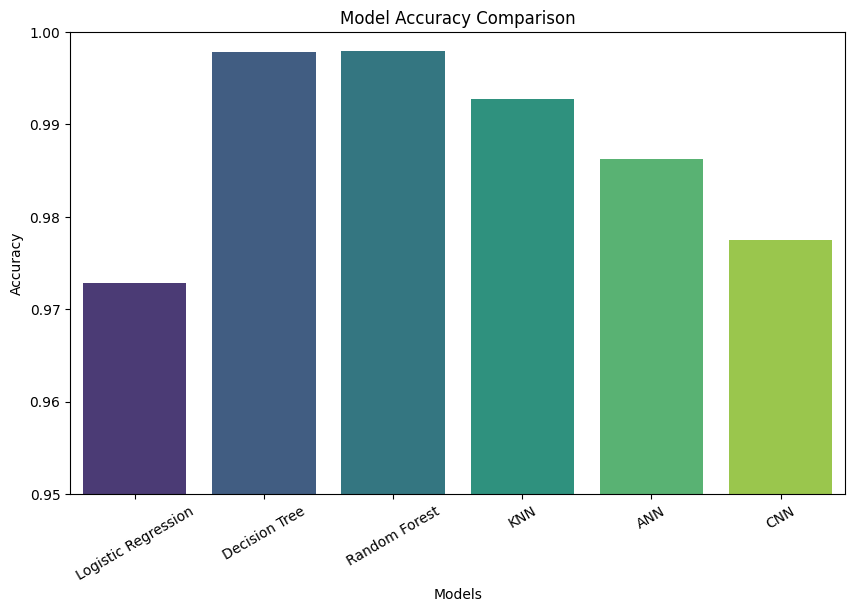

In [16]:
# Model Accuracy Comparison

results = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "Decision Tree": accuracy_score(y_test, pred_dt),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "KNN": accuracy_score(y_test, pred_knn),
    "ANN": ann_acc,
    "CNN": cnn_acc
}

# Print accuracy of each model
for model, acc in results.items():
    print(model, ":", acc)

# Plot comparison
plt.figure(figsize=(10,6))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.95, 1.0)

plt.xticks(rotation=30)

plt.show()